<a href="https://colab.research.google.com/github/kiransree2002/Asteroid_Diameter_prediction_Exit_Exam_Kiransreehari/blob/main/Kiran_Sree_Hari_Exit__Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

In [38]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


#Task 1 : Data Exploration & Understanding

In [5]:
file_path = "/content/drive/MyDrive/Data Set/dataset (1).csv"
df_astro = pd.read_csv(file_path)
df_astro.head()

/tmp/ipykernel_2706/3526753401.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_astro = pd.read_csv(file_path)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [6]:
df_astro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [7]:
df_astro.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [8]:
df_astro.shape

(958524, 45)

In [9]:
# fetching numerical columns
num_cols = df_astro.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['spkid', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch',
       'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad',
       'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e',
       'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma',
       'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms'],
      dtype='object')


In [10]:
# fetching categorical columns
cat_cols = df_astro.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id',
       'equinox', 'class'],
      dtype='object')


In [11]:
#missing value analyzing
df_astro.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [12]:
#duplicate checking
df_astro.duplicated().sum()

np.int64(0)

### Distribution of Asteroid Classes

/tmp/ipykernel_2706/702028436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_astro, order=df_astro['class'].value_counts().index, palette='viridis')


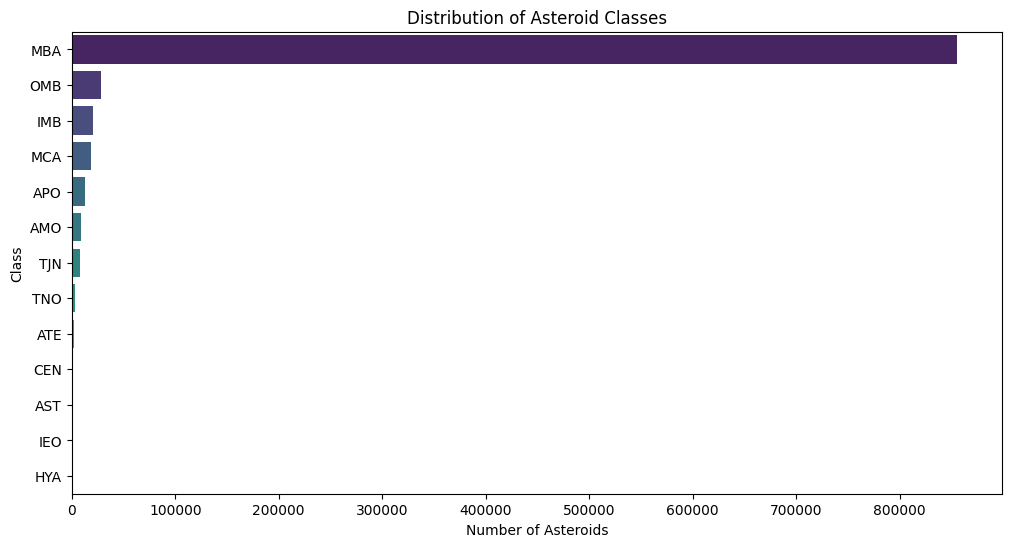

In [39]:
plt.figure(figsize=(12, 6))
sns.countplot(y='class', data=df_astro, order=df_astro['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Asteroid Classes')
plt.xlabel('Number of Asteroids')
plt.ylabel('Class')
plt.show()

### Distribution of Absolute Magnitude (H)

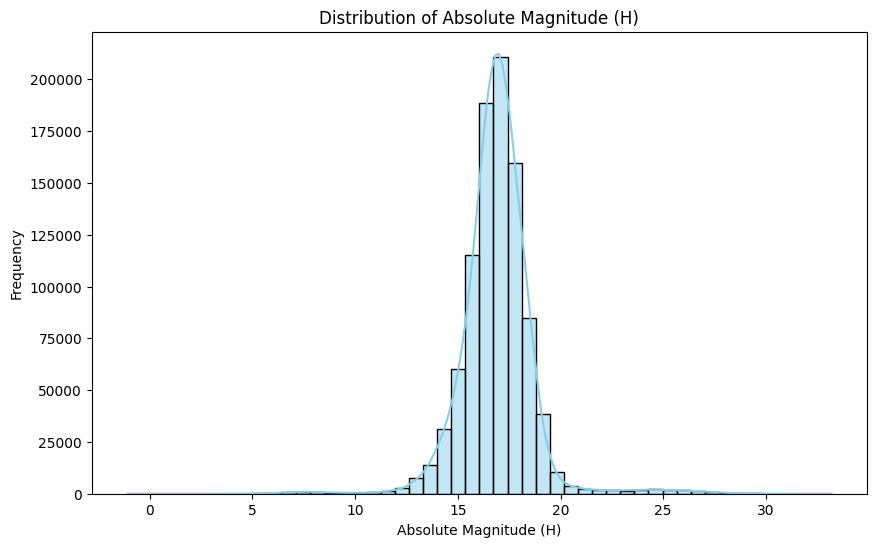

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df_astro['H'].dropna(), kde=True, bins=50, color='skyblue')
plt.title('Distribution of Absolute Magnitude (H)')
plt.xlabel('Absolute Magnitude (H)')
plt.ylabel('Frequency')
plt.show()

### Distribution of Diameter (Note: Many missing values)

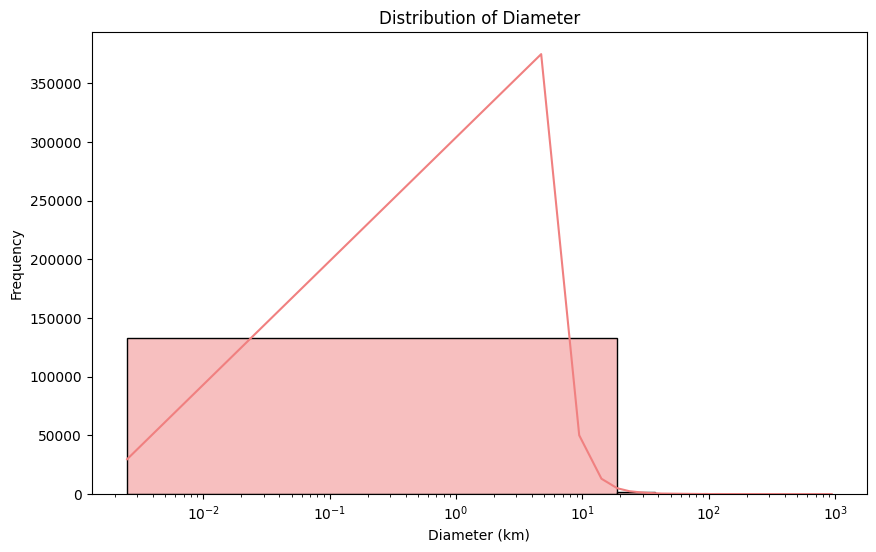

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df_astro['diameter'].dropna(), kde=True, bins=50, color='lightcoral')
plt.title('Distribution of Diameter')
plt.xlabel('Diameter (km)')
plt.ylabel('Frequency')
plt.xscale('log') # Use log scale for better visualization due to wide range
plt.show()

### Relationship between Diameter and Absolute Magnitude (H)

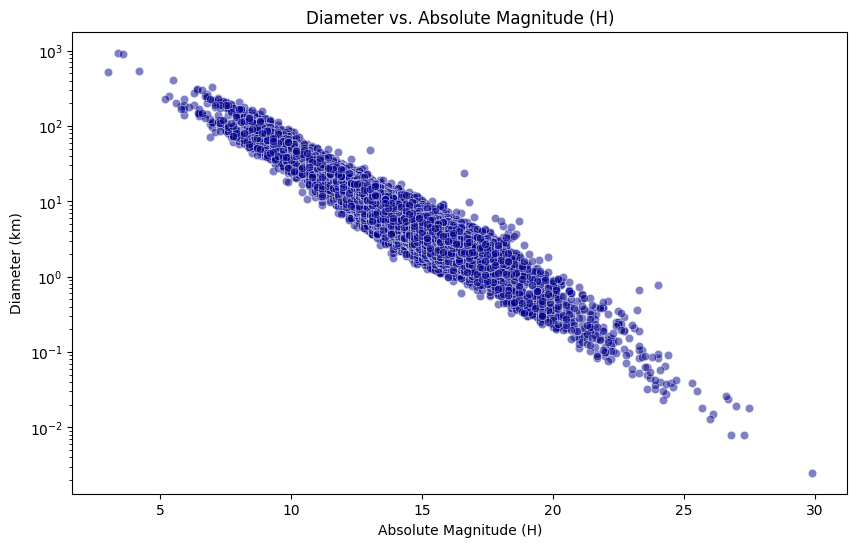

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='H', y='diameter', data=df_astro, alpha=0.5, color='darkblue')
plt.title('Diameter vs. Absolute Magnitude (H)')
plt.xlabel('Absolute Magnitude (H)')
plt.ylabel('Diameter (km)')
plt.xscale('linear') # H is linear
plt.yscale('log') # Diameter has a wide range, use log scale for better visualization
plt.show()

### Relationship between Diameter and Albedo

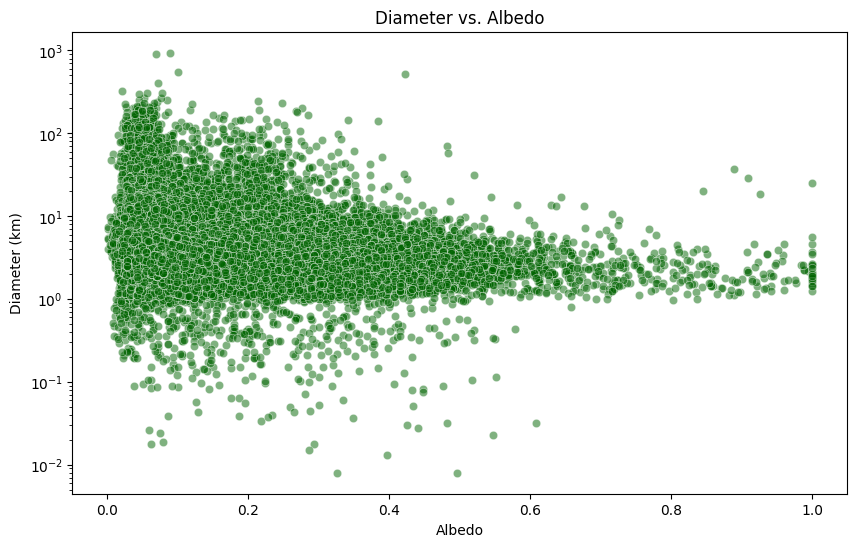

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='albedo', y='diameter', data=df_astro, alpha=0.5, color='darkgreen')
plt.title('Diameter vs. Albedo')
plt.xlabel('Albedo')
plt.ylabel('Diameter (km)')
plt.xscale('linear')
plt.yscale('log') # Diameter has a wide range, use log scale for better visualization
plt.show()

Analytical questions
1. The plot clearly shows that the asteroid diameter is not normally distributed. When plotted on a linear scale, it would be highly skewed to the right, with many small asteroids and very few large ones. Using a logarithmic scale for the x-axis (as in the plot) helps to visualize the wide range of diameters, but it still demonstrates a distribution that is far from a symmetric bell curve, with a peak at smaller diameters.

2. Based on the initial exploratory data analysis (EDA) plots:

Absolute Magnitude (H): The scatter plot "Diameter vs. Absolute Magnitude (H)" (cell b4f20c33) shows a very strong, almost linear, negative correlation when diameter is on a log scale. As H increases (meaning the asteroid is fainter), the diameter decreases. This is expected, as H is inversely related to an object's intrinsic brightness and thus its size.

Albedo: The "Diameter vs. Albedo" scatter plot (cell d10ef8f7) shows a weaker, less clear relationship compared to H. While there's a general trend, the scatter is much wider, indicating albedo alone is not as strong a predictor as H.

To confirm, we can calculate the correlation coefficients once the regression model is built and the relevant features are selected.

#Task 2 : Data Preprocessing & feature Engineering

### Handling Missing Values

In [44]:
# Calculate the percentage of missing values for each column
missing_percentages = df_astro.isnull().sum() / len(df_astro) * 100

# Identify columns to drop (e.g., more than 80% missing)
drop_cols = missing_percentages[missing_percentages > 80].index.tolist()
print(f"Columns to drop due to high missing values: {drop_cols}")

df_astro_cleaned = df_astro.drop(columns=drop_cols)
print(f"Shape after dropping high missing columns: {df_astro_cleaned.shape}")

Columns to drop due to high missing values: ['name', 'prefix', 'diameter', 'albedo', 'diameter_sigma']
Shape after dropping high missing columns: (958524, 40)


In [45]:
# Separate numerical and categorical columns from the cleaned dataframe
num_cols_cleaned = df_astro_cleaned.select_dtypes(include=['int64', 'float64']).columns
cat_cols_cleaned = df_astro_cleaned.select_dtypes(include=['object']).columns

# Impute numerical columns with the median
for col in num_cols_cleaned:
    if df_astro_cleaned[col].isnull().any():
        median_val = df_astro_cleaned[col].median()
        df_astro_cleaned[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute categorical columns with the mode
for col in cat_cols_cleaned:
    if df_astro_cleaned[col].isnull().any():
        mode_val = df_astro_cleaned[col].mode()[0] # .mode() can return multiple if ties
        df_astro_cleaned[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

# Verify no more missing values
print("\nMissing values after imputation:")
print(df_astro_cleaned.isnull().sum().sum()) # Should be 0

/tmp/ipykernel_2706/1753291686.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_astro_cleaned[col].fillna(median_val, inplace=True)


Imputed numerical column 'H' with median: 16.9
Imputed numerical column 'ma' with median: 175.6410780755812
Imputed numerical column 'ad' with median: 3.0469947441347482
Imputed numerical column 'per' with median: 1572.9756299372666
Imputed numerical column 'per_y' with median: 4.30657093464213
Imputed numerical column 'moid' with median: 1.24085
Imputed numerical column 'moid_ld' with median: 477.706175
Imputed numerical column 'sigma_e' with median: 8.1716e-08
Imputed numerical column 'sigma_a' with median: 3.84915e-08
Imputed numerical column 'sigma_q' with median: 2.2719e-07
Imputed numerical column 'sigma_i' with median: 8.6888e-06
Imputed numerical column 'sigma_om' with median: 6.642550000000001e-05
Imputed numerical column 'sigma_w' with median: 0.00010471
Imputed numerical column 'sigma_ma' with median: 4.9001e-05
Imputed numerical column 'sigma_ad' with median: 4.359e-08
Imputed numerical column 'sigma_n' with median: 4.638e-09
Imputed numerical column 'sigma_tp' with median:

/tmp/ipykernel_2706/1753291686.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_astro_cleaned[col].fillna(mode_val, inplace=True)


Imputed categorical column 'neo' with mode: N
Imputed categorical column 'pha' with mode: N

Missing values after imputation:
0


In [46]:
display(df_astro_cleaned.head())

,id,spkid,full_name,pdes,neo,pha,H,orbit_id,epoch,epoch_mjd,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,N,N,3.40,JPL 47,2458600.5,58600,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,N,N,4.20,JPL 37,2459000.5,59000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,N,N,5.33,JPL 112,2459000.5,59000,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,N,N,3.00,JPL 35,2458600.5,58600,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,N,N,6.90,JPL 114,2459000.5,59000,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


### Removing Irrelevant Identifiers

In [47]:
irrelevant_cols = ['id', 'spkid', 'full_name', 'pdes', 'orbit_id', 'equinox']

# Filter out columns that are not present in df_astro_cleaned
irrelevant_cols_to_drop = [col for col in irrelevant_cols if col in df_astro_cleaned.columns]

df_astro_cleaned = df_astro_cleaned.drop(columns=irrelevant_cols_to_drop)
print(f"Columns dropped: {irrelevant_cols_to_drop}")
print(f"Shape after dropping irrelevant identifiers: {df_astro_cleaned.shape}")
display(df_astro_cleaned.head())

Columns dropped: ['id', 'spkid', 'full_name', 'pdes', 'orbit_id', 'equinox']
Shape after dropping irrelevant identifiers: (958524, 34)


,neo,pha,H,epoch,epoch_mjd,epoch_cal,e,a,q,i,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,N,3.40,2458600.5,58600,20190427.0,0.076009,2.769165,2.558684,10.594067,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,N,4.20,2459000.5,59000,20200531.0,0.229972,2.773841,2.135935,34.832932,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,N,5.33,2459000.5,59000,20200531.0,0.256936,2.668285,1.982706,12.991043,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,N,3.00,2458600.5,58600,20190427.0,0.088721,2.361418,2.151909,7.141771,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,N,6.90,2459000.5,59000,20200531.0,0.190913,2.574037,2.082619,5.367427,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


### One-Hot Encoding Categorical Variables

In [48]:
# Identify remaining categorical columns (excluding the target 'class' column)
remaining_cat_cols = df_astro_cleaned.select_dtypes(include=['object']).columns.tolist()
if 'class' in remaining_cat_cols:
    remaining_cat_cols.remove('class')

print(f"Categorical columns to encode: {remaining_cat_cols}")

# Apply one-hot encoding
df_astro_encoded = pd.get_dummies(df_astro_cleaned, columns=remaining_cat_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_astro_encoded.shape}")
display(df_astro_encoded.head())

Categorical columns to encode: ['neo', 'pha']
Shape after one-hot encoding: (958524, 34)


,H,epoch,epoch_mjd,epoch_cal,e,a,q,i,om,w,...,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms,neo_Y,pha_Y
0,3.40,2458600.5,58600,20190427.0,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,...,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301,False,False
1,4.20,2459000.5,59000,20200531.0,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,...,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936,False,False
2,5.33,2459000.5,59000,20200531.0,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,...,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848,False,False
3,3.00,2458600.5,58600,20190427.0,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,...,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980,False,False
4,6.90,2459000.5,59000,20200531.0,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,...,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191,False,False


### Scaling Numerical Features

In [49]:
# Identify numerical columns for scaling (exclude 'class' if it's numerical and the target)
# First, ensure 'class' column is excluded from numerical columns if it's present and numeric
numerical_features = df_astro_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'class' in numerical_features:
    numerical_features.remove('class')

print(f"Numerical features to scale: {numerical_features}")

scaler = StandardScaler()
df_astro_scaled = df_astro_encoded.copy()
df_astro_scaled[numerical_features] = scaler.fit_transform(df_astro_encoded[numerical_features])

print("Shape after scaling numerical features:", df_astro_scaled.shape)
display(df_astro_scaled.head())

Numerical features to scale: ['H', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']
Shape after scaling numerical features: (958524, 34)


,H,epoch,epoch_mjd,epoch_cal,e,a,q,i,om,w,...,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms,neo_Y,pha_Y
0,-7.568521,-0.383060,-0.383060,-0.336625,-0.864692,-0.003348,0.076567,0.231884,-0.856818,-1.037385,...,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,MBA,-0.046670,False,False
1,-7.120228,0.187008,0.187008,0.186803,0.797214,-0.003230,-0.121049,3.883607,0.044404,1.240114,...,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,MBA,-0.073494,False,False
2,-6.487013,0.187008,0.187008,0.186803,1.088270,-0.005888,-0.192676,0.593002,0.013560,0.642007,...,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,MBA,-0.081099,False,False
3,-7.792668,-0.383060,-0.383060,-0.336625,-0.727472,-0.013614,-0.113581,-0.288224,-0.628349,-0.294942,...,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,MBA,-0.058766,False,False
4,-5.607237,0.187008,0.187008,0.186803,0.375605,-0.008261,-0.145971,-0.555539,-0.261323,1.706444,...,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,MBA,-0.014292,False,False


### Selecting Features and Target Variable

In [50]:
# Define features (X) and target (y)
X = df_astro_scaled.drop('class', axis=1)
y = df_astro_scaled['class']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

display(X.head())

Shape of features (X): (958524, 33)
Shape of target (y): (958524,)


,H,epoch,epoch_mjd,epoch_cal,e,a,q,i,om,w,...,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms,neo_Y,pha_Y
0,-7.568521,-0.383060,-0.383060,-0.336625,-0.864692,-0.003348,0.076567,0.231884,-0.856818,-1.037385,...,-0.003941,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,-0.046670,False,False
1,-7.120228,0.187008,0.187008,0.186803,0.797214,-0.003230,-0.121049,3.883607,0.044404,1.240114,...,-0.003941,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,-0.073494,False,False
2,-6.487013,0.187008,0.187008,0.186803,1.088270,-0.005888,-0.192676,0.593002,0.013560,0.642007,...,-0.003941,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,-0.081099,False,False
3,-7.792668,-0.383060,-0.383060,-0.336625,-0.727472,-0.013614,-0.113581,-0.288224,-0.628349,-0.294942,...,-0.003941,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,-0.058766,False,False
4,-5.607237,0.187008,0.187008,0.186803,0.375605,-0.008261,-0.145971,-0.555539,-0.261323,1.706444,...,-0.003941,-0.00148,-0.00148,-0.002931,-0.005102,-0.001445,-0.003048,-0.014292,False,False


### Encoding Target Variable and Data Splitting

In [51]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode the target variable 'y'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

num_classes = len(label_encoder.classes_)
print(f"Number of unique classes: {num_classes}")

X_train shape: (766819, 33)
X_test shape: (191705, 33)
y_train shape: (766819,)
y_test shape: (191705,)
Number of unique classes: 13


#Task 3 Deep Neural Network development

### Deep Neural Network Architecture

In [52]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer encoded labels
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,453 (52.55 KB)

 Trainable params: 13,453 (52.55 KB)

 Non-trainable params: 0 (0.00 B)

### Hyperparameter Tuning using Keras Tuner

In [53]:
import keras_tuner as kt

# Define the build model function for Keras Tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.InputLayer(input_shape=(X_train.shape[1],)))

    # Tune the number of units in the first Dense layer
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Tune the dropout rate
    hp_dropout = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(64, activation='relu')) # Second layer, fixed units for now
    model.add(layers.Dropout(0.3)) # Second dropout, fixed for now
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [54]:
# Initialize the Keras Tuner (RandomSearch)
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='asteroid_classification_hp'
)

# Print a summary of the search space
tuner.search_space_summary()

Search space summary
Default search space size: 3
units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [57]:
# Start the hyperparameter search
tuner.search(X_train, y_train, epochs=1, validation_data=(X_test, y_test))

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The optimal number of units in the first dense layer is {best_hps.get('units')}")
print(f"The optimal dropout rate for the first dropout layer is {best_hps.get('dropout_1')}")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 02m 48s]
val_accuracy: 0.9654182195663452

Best val_accuracy So Far: 0.9938160181045532
Total elapsed time: 00h 52m 37s
The optimal number of units in the first dense layer is 192
The optimal dropout rate for the first dropout layer is 0.2
The optimal learning rate for the optimizer is 0.0001


In [59]:
# Build the best model found by the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test data
print("\nEvaluating the best model:")
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

best_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Evaluating the best model:
Test Loss: 0.0735
Test Accuracy: 0.9939


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,725 (77.05 KB)

 Trainable params: 19,725 (77.05 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Re-train the best model to get its training history
history = best_model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/5
23964/23964 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - accuracy: 0.9917 - loss: 0.0433 - val_accuracy: 0.9947 - val_loss: 0.0707
Epoch 2/5
23964/23964 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - accuracy: 0.9925 - loss: 0.0311 - val_accuracy: 0.9960 - val_loss: 0.0719
Epoch 3/5
23964/23964 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - accuracy: 0.9930 - loss: 0.0335 - val_accuracy: 0.9958 - val_loss: 0.0748
Epoch 4/5
23964/23964 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9934 - loss: 0.0269 - val_accuracy: 0.9962 - val_loss: 0.0748
Epoch 5/5
23964/23964 ━━━━━━━━━━━━━━━━━━━━ 90s 4ms/step - accuracy: 0.9938 - loss: 0.0315 - val_accuracy: 0.9965 - val_loss: 0.0689


The plot below visualizes the training and validation loss over the epochs. This helps in understanding if the model is overfitting or underfitting the data.

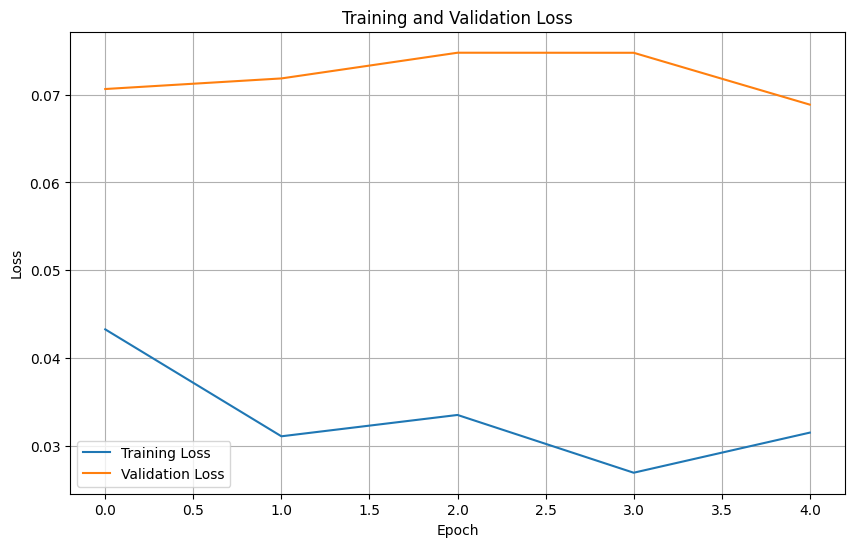

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#Task 4 : Model Evaluation & Error Analysis

In [70]:
joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [71]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>